In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import os, sys
import glob

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as tkr

import cmocean
#import seaborn as sns
#sns.set_style('ticks')

from scipy import stats
from scipy.stats import percentileofscore

from datetime import datetime, timedelta
from vtools.functions.filter import cosine_lanczos
from vtools.data.vtime import days, hours, minutes
from vtools.functions.unit_conversions import ec_psu_25c

from mpl_toolkits.axes_grid1.inset_locator import inset_axes


In [2]:
#function comes from schimpy metricsplot.py script https://github.com/CADWRDeltaModeling/schimpy/blob/master/schimpy/metricsplot.py
def filter_timeseries(tss, cutoff_period=hours(40)):
    filtered = []
    ts=tss #try removing the loop for now
    if ts is None:
        filtered.append(None)
    else:
        #print(ts)
        ts_filtered = cosine_lanczos(ts, cutoff_period=cutoff_period)
        ts_filtered.filtered = 'cosine_lanczos'
    return ts_filtered

In [3]:
dtformat = '%Y-%m-%d %H:%M:%S'
jp=pd.read_csv('/global/scratch/users/jennaisrael/time_varying_data/dmsdatastore/salinity/jersey_point_jer_sjj_filled_cl_filtered.csv')
jp['datetime']=pd.to_datetime(jp['datetime'],format=dtformat)
jp.set_index("datetime",inplace=True)
jp

,Salinity[mS/cm]
datetime,
2009-08-29 15:15:00,NaN
2009-08-29 15:30:00,NaN
2009-08-29 15:45:00,NaN
2009-08-29 16:00:00,NaN
2009-08-29 16:15:00,NaN
...,...
2025-09-07 22:00:00,NaN
2025-09-07 22:15:00,NaN
2025-09-07 22:30:00,NaN


In [4]:
#add a column for water year
jp['year']=jp.index.year
jp['month']=jp.index.month
jp['calwy']=np.ones_like(jp['month'])
jp['calwy']=jp['calwy'].where(jp['month']>9,0)
jp['wy']=jp['year']+jp['calwy']

<Axes: xlabel='datetime'>

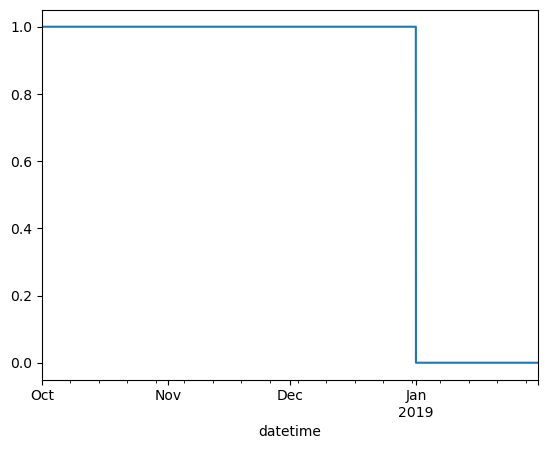

In [5]:
jp['calwy'][pd.to_datetime('2018-10-1'):pd.to_datetime('2019-1-31')].plot()

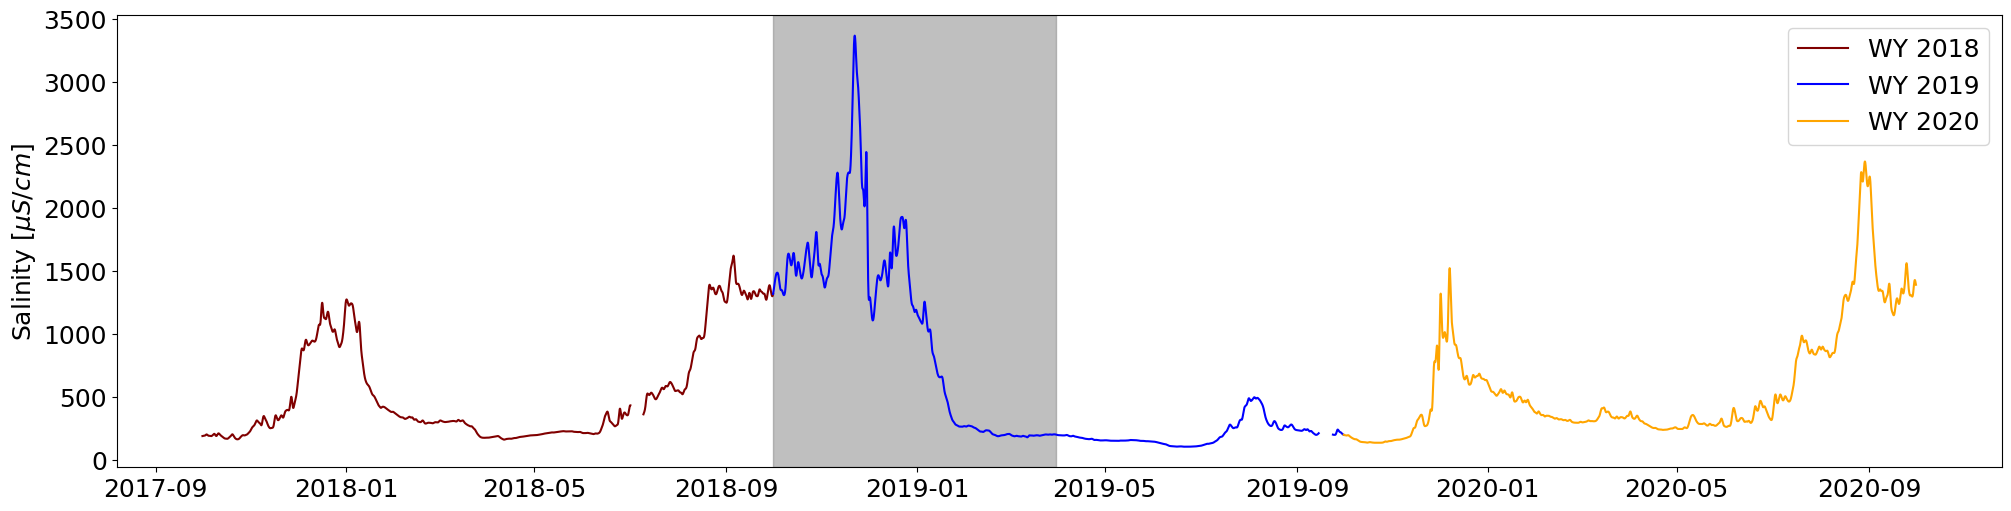

In [7]:
fig, ax = plt.subplots(layout='constrained',figsize= (20,5))
# ax = fig.add_subplot(121)
# setting font sizeto 30
plt.rcParams.update({'font.size': 18})

ax.plot(jp['Salinity[mS/cm]'].where(jp['wy']==2018), label="WY 2018",color='maroon')
ax.plot(jp['Salinity[mS/cm]'].where(jp['wy']==2019), label="WY 2019",color='b')
ax.plot(jp['Salinity[mS/cm]'].where(jp['wy']==2020), label="WY 2020",color='orange')
#ax[0].plot(jer_dms_filtc.loc['2012']['jer_S[mS/cm]'], label="2012",color='maroon')
# ax[1].plot(sjj_dms_filtc.loc['2012'].xaxis, sjj_dms_filtc.loc['2012']['sjj_S[psu]'],color='maroon')

# ax[1].plot(jer_dms_filtc.loc['2015'].xaxis, jer_dms_filtc.loc['2015']['jer_S[psu]'], label="2015",color='b',linestyle='--')
# ax[1].plot(sjj_dms_filtc.loc['2015'].xaxis, sjj_dms_filtc.loc['2015']['sjj_S[psu]'], color='b',linestyle='--')

# ax[1].plot(jer_dms_filtc.loc['2017'].xaxis, jer_dms_filtc.loc['2017']['jer_S[psu]'], label="2017",color='orange',linestyle=':')
# ax[1].plot(sjj_dms_filtc.loc['2017'].xaxis, sjj_dms_filtc.loc['2017']['sjj_S[psu]'],color='orange',linestyle=':')
ax.legend()
ax.set_ylabel(r"Salinity [$\mu S/ cm$]")

# # create inset plot
# sub_ax1 = inset_axes(
#     parent_axes=ax,
#     width="40%",
#     height="30%",
#     borderpad=1  # padding between parent and inset axes
# )

# sub_ax1.plot(jp['Salinity[mS/cm]'][pd.to_datetime('2018-10-1'):pd.to_datetime('2019-1-31')])
# sub_ax1.set_ylabel('Intensity Frequency')
# sub_ax1.set_xlabel('Intensity [m]')


ax.axvspan(pd.to_datetime('2018-10-1'),pd.to_datetime('2019-3-31'), color="grey", alpha=0.5)
#ax.xticks(rotation=30)
plt.show()
fig.savefig('/global/scratch/users/jennaisrael/Plotting/ch_3/figures/wy_2018_salinity_shademarch.png')

In [ ]:
# code for inset plot

# # main plot
# # Plot intensity- duration for each location
# #add colorbar
# #trim the colormap so we don't have a white or yellow end
cmap = cmocean.cm.phase
cmap_cropped = cmocean.tools.crop_by_percent(cmap, 20, which='both', N=None)
# newcmap = cmocean.tools.crop_by_percent(cmap, 5, which='max', N=7)
# #newcmap=plt.get_cmap(cmap_cropped, 6)

#try discrete colormap
newcmap=plt.cm.get_cmap('cool',lut=6)

# plt.figure()
# cmap = cm.GMT_drywet._resample(6)
# pm = plt.pcolormesh(np.random.rand(10,8), cmap=cmap)
# plt.colorbar(pm, orientation='horizontal')
# plt.show()


# 
# # extract all colors from the .jet map
# cmaplist = [cmap_cropped(i) for i in range(cmap_cropped.N)]
# # create the new map
# newcmap = mpl.colors.LinearSegmentedColormap.from_list(
#    'Custom cmap', cmaplist, cmap_cropped.N)


#fig, ax = plt.subplots(1,3,layout='constrained',figsize= (20,10))
fig = plt.figure(layout='constrained',figsize= (25,10))
ax = fig.add_subplot(131)
# setting font sizeto 30
plt.rcParams.update({'font.size': 18})
pts0=plt.scatter(dur_pr/24,inten_u_pr,c=mfc_pr,cmap=newcmap,s=150)
addr2(dur_pr/24,inten_u_pr)
plt.xlabel('peak width (days)')
plt.ylabel('elevation intensity (m)')
#ax[1].set_xlim(0,12)
plt.title('Point Reyes NTR peak')

# create inset plot
sub_ax1 = inset_axes(
    parent_axes=ax,
    width="40%",
    height="30%",
    borderpad=1  # padding between parent and inset axes
)

sub_ax1.hist(inten_u_pr)
sub_ax1.set_ylabel('Intensity Frequency')
sub_ax1.set_xlabel('Intensity [m]')

ax = fig.add_subplot(132)
pts1=plt.scatter(dur_jp/24,inten_u_jp,c=mfc_jp,cmap=newcmap,s=150)
addr2(dur_jp/24,inten_u_jp)
plt.xlabel('peak width (days)')
plt.ylabel('salinity intensity ($\mu S/cm$)')
#ax[1].set_xlim(0,12)
plt.title('Jersey Point salinity peak')

ax = fig.add_subplot(133)
pts2=plt.scatter(dur_frk/24,inten_u_frk,c=mfc_frk,cmap=newcmap,s=150)
addr2(dur_frk/24,inten_u_frk)
plt.xlabel('peak width (days)')
plt.ylabel('salinity intensity ($\mu S/cm$)')
#ax[1].set_xlim(0,12)
plt.title('Franks Tract salinity peak')

# create inset plot
sub_ax = inset_axes(
    parent_axes=ax,
    width="40%",
    height="30%",
    borderpad=1  # padding between parent and inset axes
)

# add content inside inset plot
# sub_ax.bar(x,N,color=newcmap(x/7))
# sub_ax.set_xticks(x)
# sub_ax.set_xticklabels(mon)
# sub_ax.set_ylabel('Number of events')

N, bins, patches=sub_ax.hist(mfc_pr,bins=np.arange(6.5,13.5))
idx = 1
for thisbin, thispatch in zip(bins, patches):
    color = newcmap(idx/7)[:-1]
    thispatch.set_facecolor(color)
    idx=idx+1
sub_ax.set_xticks(np.arange(7,13))
sub_ax.set_xticklabels(['July','Aug','Sept','Oct','Nov','Dec'],rotation=90)
sub_ax.set_ylabel('Event Frequency')


# mat = plt.matshow(mfc_pr, cmap=newcmap, vmin=np.min(mfc_pr) - 0.5, vmax=np.max(mfc_pr) + 0.5)
#     # tell the colorbar to tick at integers
# cax = plt.colorbar(mat, ticks=np.arange(np.min(mfc_pr), np.max(mfc_pr) + 1))

cbar=fig.colorbar(pts2, ax=ax)
cbar.set_ticks(ticks=np.arange(7,13), labels=['July','Aug','Sept','Oct','Nov','Dec'])


plt.show()
fig.savefig('/global/scratch/users/jennaisrael/climate_data_processing/identify_stp/manuscript_figures/intensity_duration_inset_newcmap_newinset_more_events_computedintensity.png')